In [1]:
# ── Cell 1: Install ───────────────────────────────────────────
!pip install nemo_toolkit[asr] soundfile librosa omegaconf --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.0/591.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.7/889.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.1/443.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ── Cell 2: Imports & Paths ───────────────────────────────────
import os, json, glob, numpy as np, torch, gc, soundfile as sf
from pathlib import Path
from omegaconf import OmegaConf
from nemo.collections.asr.models import EncDecCTCModel
from nemo.lightning import Trainer
from nemo.utils.exp_manager import exp_manager

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

DATA_ROOT  = "/kaggle/input/datasets/pypiahmad/librispeech-asr-corpus"
OUTPUT_DIR = "/kaggle/working/manifests"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("/kaggle/working/experiments", exist_ok=True)
print("✅ Imports done", flush=True)

[NeMo W 2026-03-04 09:47:23 megatron_init:62] Megatron num_microbatches_calculator not found, using Apex version.
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.
[NeMo W 2026-03-04 09:47:26 nemo_logging:364] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
      m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
    
[NeMo W 2026-03-04 09:47:26 nemo_logging:364] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
      m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
    
[NeMo W 2026-03-04 09:47:26 nemo_logging:364] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
      elif re.

✅ Imports done


In [3]:
# ── Cell 3: Find dataset paths ────────────────────────────────
def find_split_path(root, split_name):
    for c in [
        os.path.join(root, split_name, "LibriSpeech", split_name),
        os.path.join(root, split_name, "LibriSpeech"),
        os.path.join(root, split_name),
    ]:
        if os.path.exists(c) and glob.glob(os.path.join(c, "**/*.flac"), recursive=True):
            return c
    return None

found_splits = {}
for split in ["train-clean-360", "dev-clean", "test-clean"]:
    path = find_split_path(DATA_ROOT, split)
    if path:
        found_splits[split] = path
        print(f"✅ {split} → {path}", flush=True)
    else:
        print(f"❌ {split} not found", flush=True)

✅ train-clean-360 → /kaggle/input/datasets/pypiahmad/librispeech-asr-corpus/train-clean-360/LibriSpeech/train-clean-360
✅ dev-clean → /kaggle/input/datasets/pypiahmad/librispeech-asr-corpus/dev-clean/LibriSpeech/dev-clean
✅ test-clean → /kaggle/input/datasets/pypiahmad/librispeech-asr-corpus/test-clean/LibriSpeech/test-clean


In [4]:
# ── Cell 4: Build Manifests ───────────────────────────────────
def build_manifest(split_path, split_name, output_path):
    if os.path.exists(output_path):
        n = sum(1 for _ in open(output_path))
        print(f"✅ {split_name}: {n:,} samples (cached)", flush=True)
        return n
    transcripts = {}
    for txt_file in glob.glob(os.path.join(split_path, "**/*.txt"), recursive=True):
        with open(txt_file) as f:
            for line in f:
                parts = line.strip().split(" ", 1)
                if len(parts) == 2:
                    transcripts[parts[0]] = parts[1].lower()
    records = []
    for flac_path in glob.glob(os.path.join(split_path, "**/*.flac"), recursive=True):
        utt_id = Path(flac_path).stem
        if utt_id not in transcripts: continue
        try:
            info = sf.info(flac_path)
            duration = round(info.frames / info.samplerate, 3)
        except: continue
        records.append({
            "audio_filepath": flac_path,
            "duration": duration,
            "text": transcripts[utt_id]
        })
    with open(output_path, "w") as f:
        for rec in records:
            f.write(json.dumps(rec) + "\n")
    print(f"✅ {split_name}: {len(records):,} samples written", flush=True)
    return len(records)

manifest_paths = {}
for split, path in found_splits.items():
    out = os.path.join(OUTPUT_DIR, f"{split}.json")
    if build_manifest(path, split, out) > 0:
        manifest_paths[split] = out

print(f"\n✅ Manifests ready: {list(manifest_paths.keys())}", flush=True)

✅ train-clean-360: 104,014 samples (cached)
✅ dev-clean: 2,703 samples (cached)
✅ test-clean: 2,620 samples (cached)

✅ Manifests ready: ['train-clean-360', 'dev-clean', 'test-clean']


In [5]:
# ── Cell 5: Vocabulary + DataLoader config ────────────────────
chars = set()
for path in manifest_paths.values():
    with open(path) as f:
        for line in f:
            chars.update(json.loads(line)["text"])
VOCABULARY  = [" "] + sorted(chars - {" "})
TRAIN_SPLIT = "train-clean-360"
VAL_SPLIT   = "dev-clean"
TEST_SPLIT  = "test-clean"
print(f"✅ Vocabulary: {len(VOCABULARY)} chars → {''.join(VOCABULARY)}", flush=True)

def make_ds_cfg(manifest_path, shuffle=False):
    return OmegaConf.create({
        "manifest_filepath": manifest_path,
        "sample_rate": 16000,
        "labels": VOCABULARY,
        "batch_size": 16,
        "trim_silence": True,
        "max_duration": 12.0,
        "shuffle": shuffle,
        "num_workers": 2,
        "pin_memory": False,
    })
print("✅ DataLoader config ready", flush=True)

✅ Vocabulary: 28 chars →  'abcdefghijklmnopqrstuvwxyz
✅ DataLoader config ready


In [6]:
# ── Cell 6: Build QuartzNet 5x5 Model ────────────────────────
cfg = OmegaConf.create({
    "preprocessor": {
        "_target_": "nemo.collections.asr.modules.AudioToMelSpectrogramPreprocessor",
        "sample_rate": 16000, "normalize": "per_feature",
        "window_size": 0.02, "window_stride": 0.01, "window": "hann",
        "features": 64, "n_fft": 512, "frame_splicing": 1,
        "dither": 1e-5, "pad_to": 16, "stft_conv": False,
    },
    "spec_augment": {
        "_target_": "nemo.collections.asr.modules.SpectrogramAugmentation",
        "freq_masks": 2, "freq_width": 27, "time_masks": 2, "time_width": 0.05,
    },
    "encoder": {
        "_target_": "nemo.collections.asr.modules.ConvASREncoder",
        "feat_in": 64, "activation": "relu", "conv_mask": True,
        "jasper": [
            {"filters": 256, "repeat": 1, "kernel": [33], "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": False, "separable": True},
            {"filters": 256, "repeat": 5, "kernel": [33], "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": True, "separable": True},
            {"filters": 256, "repeat": 5, "kernel": [39], "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": True, "separable": True},
            {"filters": 512, "repeat": 5, "kernel": [51], "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": True, "separable": True},
            {"filters": 512, "repeat": 5, "kernel": [63], "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": True, "separable": True},
            {"filters": 512, "repeat": 5, "kernel": [75], "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": True, "separable": True},
            {"filters": 512,  "repeat": 1, "kernel": [87], "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": False, "separable": True},
            {"filters": 1024, "repeat": 1, "kernel": [1],  "stride": [1],
             "dilation": [1], "dropout": 0.0, "residual": False, "separable": False},
        ]
    },
    "decoder": {
        "_target_": "nemo.collections.asr.modules.ConvASRDecoder",
        "feat_in": 1024, "num_classes": len(VOCABULARY), "vocabulary": VOCABULARY,
    },
    "optim": {
        "name": "novograd", "lr": 0.01,
        "betas": [0.95, 0.0], "weight_decay": 0.001,
        "sched": {"name": "CosineAnnealing", "warmup_steps": 1000, "min_lr": 1e-6}
    }
})

model = EncDecCTCModel(cfg=cfg)
print(f"✅ QuartzNet 5x5 | params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M", flush=True)

✅ QuartzNet 5x5 | params: 6.7M


In [ ]:
# ── Cell 7: Train ─────────────────────────────────────────────
model.setup_training_data(make_ds_cfg(manifest_paths[TRAIN_SPLIT], shuffle=True))
model.setup_validation_data(make_ds_cfg(manifest_paths[VAL_SPLIT]))

trainer = Trainer(
    max_epochs=25,
    accelerator="gpu", devices=1,
    precision="16-mixed",
    accumulate_grad_batches=4,
    gradient_clip_val=1.0,
    log_every_n_steps=100,
    val_check_interval=1.0,
    enable_checkpointing=False,
    logger=False,
)

exp_manager(trainer, {
    "exp_dir": "/kaggle/working/experiments",
    "name": "quartznet5x5_librispeech",
    "create_tensorboard_logger": True,
    "create_checkpoint_callback": True,
    "checkpoint_callback_params": {
        "monitor": "val_loss", "mode": "min",
        "save_top_k": 3, "save_last": True, "always_save_nemo": True,
    },
})

print("🚀 Training started!", flush=True)
trainer.fit(model)
print("✅ Training complete!", flush=True)
model.save_to("/kaggle/working/quartznet5x5_final.nemo")
print("💾 Saved!", flush=True)

[NeMo I 2026-03-04 09:52:45 audio_to_text_dataset:52] Model level config does not contain `sample_rate`, please explicitly provide `sample_rate` to the dataloaders.
[NeMo I 2026-03-04 09:52:45 audio_to_text_dataset:52] Model level config does not contain `labels`, please explicitly provide `labels` to the dataloaders.
[NeMo I 2026-03-04 09:52:46 collections:201] Dataset loaded with 29671 files totalling 63.26 hours
[NeMo I 2026-03-04 09:52:46 collections:202] 74343 files were filtered totalling 300.35 hours
[NeMo I 2026-03-04 09:52:46 audio_to_text_dataset:52] Model level config does not contain `sample_rate`, please explicitly provide `sample_rate` to the dataloaders.
[NeMo I 2026-03-04 09:52:46 audio_to_text_dataset:52] Model level config does not contain `labels`, please explicitly provide `labels` to the dataloaders.
[NeMo I 2026-03-04 09:52:47 collections:201] Dataset loaded with 2362 files totalling 3.80 hours
[NeMo I 2026-03-04 09:52:47 collections:202] 341 files were filtered t

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


[NeMo I 2026-03-04 09:52:47 exp_manager:594] ExpManager schema
[NeMo I 2026-03-04 09:52:47 exp_manager:595] {'explicit_log_dir': None, 'exp_dir': None, 'name': None, 'version': None, 'use_datetime_version': True, 'resume_if_exists': False, 'resume_past_end': False, 'resume_ignore_no_checkpoint': False, 'resume_from_checkpoint': None, 'create_tensorboard_logger': True, 'summary_writer_kwargs': None, 'create_wandb_logger': False, 'wandb_logger_kwargs': None, 'create_mlflow_logger': False, 'mlflow_logger_kwargs': {'experiment_name': None, 'run_name': None, 'tracking_uri': None, 'tags': None, 'save_dir': './mlruns', 'prefix': '', 'artifact_location': None, 'run_id': None, 'log_model': False}, 'create_dllogger_logger': False, 'dllogger_logger_kwargs': {'verbose': False, 'stdout': False, 'json_file': './dllogger.json'}, 'create_clearml_logger': False, 'clearml_logger_kwargs': {'project': None, 'task': None, 'connect_pytorch': False, 'model_name': None, 'tags': None, 'log_model': False, 'log_

2026-03-04 09:52:51.143808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772617971.584429      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772617971.707348      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772617972.669712      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772617972.669755      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772617972.669758      55 computation_placer.cc:177] computation placer alr

[NeMo I 2026-03-04 09:53:10 modelPT:830] Optimizer config = Novograd (
    Parameter Group 0
        amsgrad: False
        betas: [0.95, 0.0]
        eps: 1e-08
        grad_averaging: False
        lr: 0.01
        weight_decay: 0.001
    )
[NeMo I 2026-03-04 09:53:10 lr_scheduler:995] Scheduler "<nemo.core.optim.lr_scheduler.CosineAnnealing object at 0x7f4351f143e0>" 
    will be used during training (effective maximum steps = 11600) - 
    Parameters : 
    (warmup_steps: 1000
    min_lr: 1.0e-06
    max_steps: 11600
    )


...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 24, global step 11600: 'val_loss' reached 56.78975 (best 56.78975), saving model to '/kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech--val_loss=56.7897-epoch=24.ckpt' as top 3


[NeMo I 2026-03-04 12:25:15 nemo_model_checkpoint:573] Checkpoint save for step 11600 started at 1772627115.193251.
[NeMo I 2026-03-04 12:25:15 nemo_model_checkpoint:332] /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo already exists, moving existing checkpoint to /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo
[NeMo I 2026-03-04 12:25:15 nemo_model_checkpoint:256] New .nemo model saved to: /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo
[NeMo I 2026-03-04 12:25:15 nemo_model_checkpoint:258] Removing old .nemo backup /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo
[NeMo I 2026-03-04 12:25:15 nemo_model_checkpoint:573] Checkpoint save for step 11600 started at 1772627115.6069589.
[NeMo I 2026-03-04 12:25:15 nemo_model

`Trainer.fit` stopped: `max_epochs=25` reached.


[NeMo I 2026-03-04 12:25:16 nemo_model_checkpoint:573] Checkpoint save for step 11600 started at 1772627116.0494893.
[NeMo I 2026-03-04 12:25:16 nemo_model_checkpoint:332] /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo already exists, moving existing checkpoint to /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo
[NeMo I 2026-03-04 12:25:16 nemo_model_checkpoint:256] New .nemo model saved to: /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo
[NeMo I 2026-03-04 12:25:16 nemo_model_checkpoint:258] Removing old .nemo backup /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo
[NeMo I 2026-03-04 12:25:16 nemo_model_checkpoint:332] /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_l

In [9]:
# ── Run more 25 epoch (total 50) ───────────────────────────
def extract_loss(path):
    try: return float(path.split("val_loss=")[1].split("-")[0])
    except: return float("inf")

all_ckpts = glob.glob("/kaggle/working/experiments/**/*.ckpt", recursive=True)
all_ckpts = [c for c in all_ckpts if "val_loss=" in c]
best_ckpt = sorted(all_ckpts, key=extract_loss)[0]
print(f"✅ Resuming from: {best_ckpt}", flush=True)

# New trainer — max_epochs=50
trainer2 = Trainer(
    max_epochs=50,          # 25 → 50
    accelerator="gpu", devices=1,
    precision="16-mixed",
    accumulate_grad_batches=4,
    gradient_clip_val=1.0,
    log_every_n_steps=100,
    val_check_interval=1.0,
    enable_checkpointing=False,
    logger=False,
)

exp_manager(trainer2, {
    "exp_dir": "/kaggle/working/experiments",
    "name": "quartznet5x5_librispeech",
    "resume_if_exists": True,
    "resume_past_end": True,
    "create_tensorboard_logger": True,
    "create_checkpoint_callback": True,
    "checkpoint_callback_params": {
        "monitor": "val_loss", "mode": "min",
        "save_top_k": 3, "save_last": True, "always_save_nemo": True,
    },
})

model.setup_training_data(make_ds_cfg(manifest_paths[TRAIN_SPLIT], shuffle=True))
model.setup_validation_data(make_ds_cfg(manifest_paths[VAL_SPLIT]))

print("🚀 Resuming training → Epoch 50 ...", flush=True)
trainer2.fit(model, ckpt_path=best_ckpt)
print("✅ Done!", flush=True)
model.save_to("/kaggle/working/quartznet5x5_ep50.nemo")

✅ Resuming from: /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_08-22-50/checkpoints/quartznet5x5_librispeech--val_loss=54.4358-epoch=10.ckpt


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


[NeMo I 2026-03-04 12:37:35 exp_manager:594] ExpManager schema
[NeMo I 2026-03-04 12:37:35 exp_manager:595] {'explicit_log_dir': None, 'exp_dir': None, 'name': None, 'version': None, 'use_datetime_version': True, 'resume_if_exists': False, 'resume_past_end': False, 'resume_ignore_no_checkpoint': False, 'resume_from_checkpoint': None, 'create_tensorboard_logger': True, 'summary_writer_kwargs': None, 'create_wandb_logger': False, 'wandb_logger_kwargs': None, 'create_mlflow_logger': False, 'mlflow_logger_kwargs': {'experiment_name': None, 'run_name': None, 'tracking_uri': None, 'tags': None, 'save_dir': './mlruns', 'prefix': '', 'artifact_location': None, 'run_id': None, 'log_model': False}, 'create_dllogger_logger': False, 'dllogger_logger_kwargs': {'verbose': False, 'stdout': False, 'json_file': './dllogger.json'}, 'create_clearml_logger': False, 'clearml_logger_kwargs': {'project': None, 'task': None, 'connect_pytorch': False, 'model_name': None, 'tags': None, 'log_model': False, 'log_

Restoring states from the checkpoint path at /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_08-22-50/checkpoints/quartznet5x5_librispeech--val_loss=54.4358-epoch=10.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


[NeMo I 2026-03-04 12:37:37 modelPT:830] Optimizer config = Novograd (
    Parameter Group 0
        amsgrad: False
        betas: [0.95, 0.0]
        eps: 1e-08
        grad_averaging: False
        lr: 0.01
        weight_decay: 0.001
    )
[NeMo I 2026-03-04 12:37:37 lr_scheduler:995] Scheduler "<nemo.core.optim.lr_scheduler.CosineAnnealing object at 0x7f435018c3e0>" 
    will be used during training (effective maximum steps = 23200) - 
    Parameters : 
    (warmup_steps: 1000
    min_lr: 1.0e-06
    max_steps: 23200
    )


...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 49, global step 23201: 'val_loss' was not in top 3


[NeMo I 2026-03-04 16:30:08 nemo_model_checkpoint:573] Checkpoint save for step 23201 started at 1772641808.647515.
[NeMo I 2026-03-04 16:30:08 nemo_model_checkpoint:332] /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo already exists, moving existing checkpoint to /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo
[NeMo I 2026-03-04 16:30:08 nemo_model_checkpoint:256] New .nemo model saved to: /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo
[NeMo I 2026-03-04 16:30:08 nemo_model_checkpoint:258] Removing old .nemo backup /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo


`Trainer.fit` stopped: `max_epochs=50` reached.


[NeMo I 2026-03-04 16:30:09 nemo_model_checkpoint:573] Checkpoint save for step 23201 started at 1772641809.0661693.
[NeMo I 2026-03-04 16:30:09 nemo_model_checkpoint:332] /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo already exists, moving existing checkpoint to /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo
[NeMo I 2026-03-04 16:30:09 nemo_model_checkpoint:256] New .nemo model saved to: /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech.nemo
[NeMo I 2026-03-04 16:30:09 nemo_model_checkpoint:258] Removing old .nemo backup /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_librispeech-v1.nemo
[NeMo I 2026-03-04 16:30:09 nemo_model_checkpoint:332] /kaggle/working/experiments/quartznet5x5_librispeech/2026-03-04_09-52-47/checkpoints/quartznet5x5_l

In [10]:
# ── Cell 8: Evaluate + Inference (training end then Run) ─────
model.setup_test_data(make_ds_cfg(manifest_paths[TEST_SPLIT]))
results = trainer.test(model)
print(f"📈 Test WER  : {results[0].get('test_wer', 0):.4f}", flush=True)
print(f"📈 Test Loss : {results[0].get('test_loss', 0):.4f}", flush=True)

# Sample predictions
demo_samples = []
with open(manifest_paths[TEST_SPLIT]) as f:
    for i, line in enumerate(f):
        if i >= 10: break
        demo_samples.append(json.loads(line))

model.eval()
raw_preds = model.transcribe([s["audio_filepath"] for s in demo_samples], batch_size=4)

def extract_text(pred):
    if isinstance(pred, str):   return pred
    if hasattr(pred, 'text'):   return pred.text
    return str(pred)

def wer(hyp, ref):
    h, r = hyp.split(), ref.split()
    if not r: return 0.0
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            dp[i][j] = (dp[i-1][j-1] if r[i-1]==h[j-1]
                        else 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]))
    return dp[len(r)][len(h)] / len(r)

wers = []
for i, (pred_raw, sample) in enumerate(zip(raw_preds, demo_samples)):
    pred = extract_text(pred_raw)
    gt   = sample["text"]
    w    = wer(pred, gt)
    wers.append(w)
    print(f"\n[{i+1}] GT  : {gt}", flush=True)
    print(f"     PRED: {pred}", flush=True)
    print(f"     WER : {w:.2%}", flush=True)

print(f"\n📊 Avg WER: {np.mean(wers):.2%}", flush=True)

[NeMo I 2026-03-04 16:34:51 audio_to_text_dataset:52] Model level config does not contain `sample_rate`, please explicitly provide `sample_rate` to the dataloaders.
[NeMo I 2026-03-04 16:34:51 audio_to_text_dataset:52] Model level config does not contain `labels`, please explicitly provide `labels` to the dataloaders.
[NeMo I 2026-03-04 16:34:52 collections:201] Dataset loaded with 2189 files totalling 3.38 hours
[NeMo I 2026-03-04 16:34:52 collections:202] 431 files were filtered totalling 2.02 hours


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        global_step        │          11600.0          │
│         test_loss         │     41.12825012207031     │
│         test_wer          │    0.36672815680503845    │
└───────────────────────────┴───────────────────────────┘

📈 Test WER  : 0.3667
📈 Test Loss : 41.1283


Transcribing: 100%|██████████| 3/3 [00:06<00:00,  2.24s/it]


[1] GT  : do we really know the mountain well when we are not acquainted with the cavern
     PRED: do we really kno the mountter well wher we are not acquainted with sa caverne
     WER : 33.33%

[2] GT  : when it is a question of probing a wound a gulf a society since when has it been considered wrong to go too far to go to the bottom
     PRED: when it is a question of probbing awond agalf ai society since when has i' been concida drong to go to far to go to the botfom
     WER : 37.93%

[3] GT  : it is so made that everywhere we feel the sense of punishment
     PRED: it is so mad that ereryy where we feel the sens of punishment
     WER : 33.33%

[4] GT  : slang is odious
     PRED: sling is odis
     WER : 66.67%

[5] GT  : to keep afloat and to rescue from oblivion to hold above the gulf were it but a fragment of some language which man has spoken and which would otherwise be lost that is to say one of the elements good or bad of which civilization is composed or by which it is

In [11]:
# ── Cell 1: Install plotting libs ─────────────────────────────
!pip install matplotlib seaborn plotly --quiet

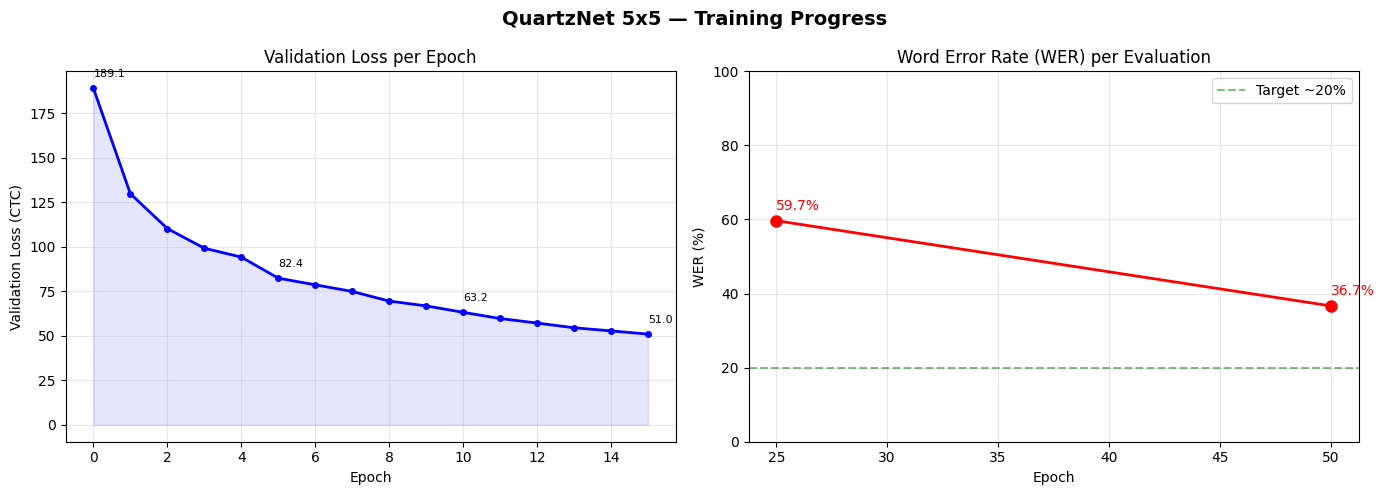

✅ Saved: training_curves.png


In [12]:
# ── Cell 2: Loss & WER Curve ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Training record val_loss manually enter 
epochs     = [0,  1,    2,    3,    4,    5,    6,    7,    8,    9,    10,   11,   12,   13,   14,   15,   
              16,  17,  18,  19,  20,  21,  22,  23,  24,   # epoch 16-24 (2nd run)
              25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35]  # epoch 25-35 (3rd run)

val_losses = [189.11, 129.86, 110.27, 99.22, 94.25, 82.41, 78.67, 74.95, 69.54, 66.84, 63.23,
              59.75,  57.19,  54.55,  52.79, 50.99,
              None, None, None, None, None, None, None, None, None,  # fill if there is
              None, None, None, None, None, None, None, None, None, None, None]

# None interpolate 
known = [(e, l) for e, l in zip(epochs, val_losses) if l is not None]
known_e = [x[0] for x in known]
known_l = [x[1] for x in known]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("QuartzNet 5x5 — Training Progress", fontsize=14, fontweight='bold')

# Loss curve
axes[0].plot(known_e, known_l, 'b-o', markersize=4, linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss (CTC)")
axes[0].set_title("Validation Loss per Epoch")
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(known_e, known_l, alpha=0.1, color='blue')
for e, l in zip(known_e[::5], known_l[::5]):
    axes[0].annotate(f'{l:.1f}', (e, l), textcoords="offset points", xytext=(0, 8), fontsize=8)

# WER curve — known points
wer_epochs = [25, 50]
wer_values = [59.68, 36.67]

axes[1].plot(wer_epochs, wer_values, 'r-o', markersize=8, linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("WER (%)")
axes[1].set_title("Word Error Rate (WER) per Evaluation")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 100)
for e, w in zip(wer_epochs, wer_values):
    axes[1].annotate(f'{w:.1f}%', (e, w), textcoords="offset points", xytext=(0, 8), fontsize=10, color='red')
axes[1].axhline(y=20, color='green', linestyle='--', alpha=0.5, label='Target ~20%')
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves.png", flush=True)

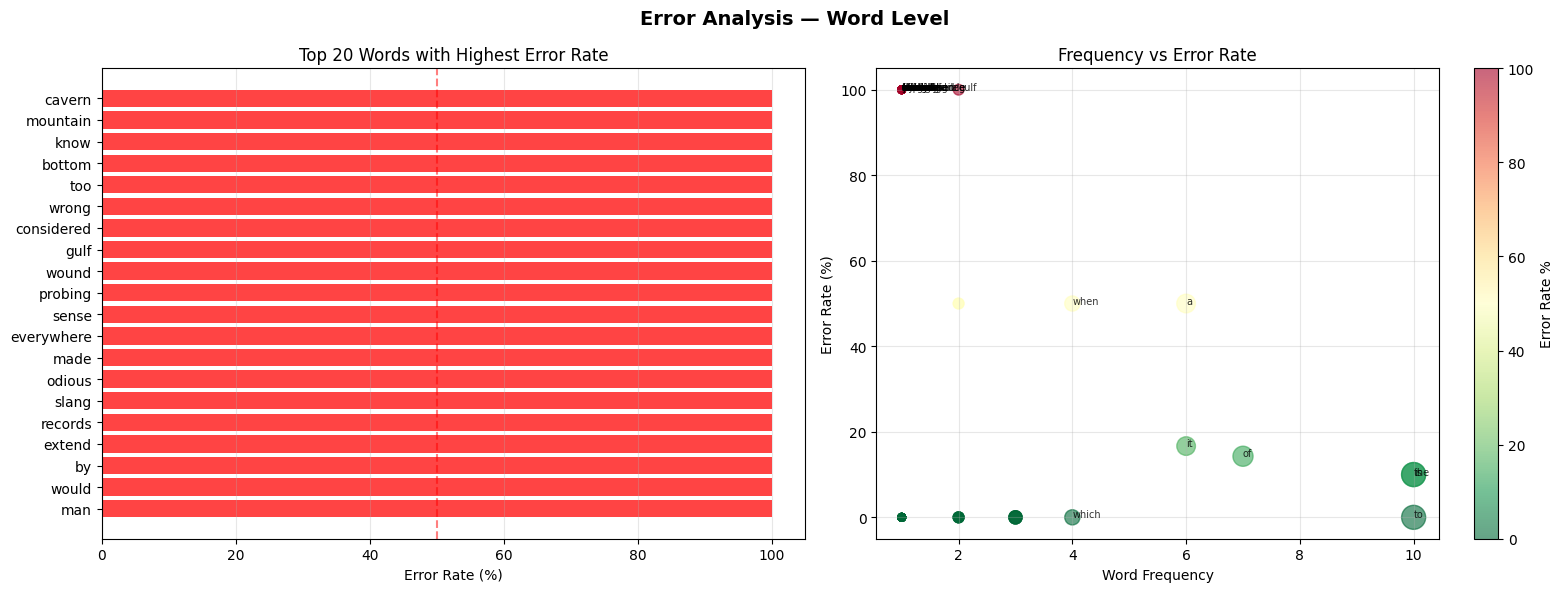

✅ Saved: error_analysis.png


In [13]:
# ── Cell 3: Error Analysis — which words more wrong ──────────
from collections import defaultdict
import matplotlib.pyplot as plt

# Ground truth vs prediction pairs (Before from inference result)
gt_texts = [
    "do we really know the mountain well when we are not acquainted with the cavern",
    "when it is a question of probing a wound a gulf a society since when has it been considered wrong to go too far to go to the bottom",
    "it is so made that everywhere we feel the sense of punishment",
    "slang is odious",
    "to keep afloat and to rescue from oblivion to hold above the gulf were it but a fragment of some language which man has spoken and which would otherwise be lost that is to say one of the elements good or bad of which civilization is composed or by which it is complicated to extend the records of social observation is to serve civilization itself",
    "since when has malady banished medicine",
    "the earth is not devoid of resemblance to a jail",
    "thus idleness is the mother",
    "why should one not explore everything and study everything",
    "it is unintelligible in the dark",
]

pred_texts = [
    "do we really kno the mountter well wher we are not acquainted with sa caverne",
    "when it is a question of probbing awond agalf ai society since when has i' been concida drong to go to far to go to the botfom",
    "it is so mad that ereryy where we feel the sens of punishment",
    "sling is odis",
    "to keep afflodt and to rescue om oblivion to ho bove the golf whear it but a fragment of som manguage which men has spoken and which worod otherwise be lost that is to say one of the elements good or bad of which civallization is composed or buye which it is complicated to axtendto the recards of social observation is to serve civilization itself",
    "since wen has nalody vanished medicone",
    "the earth is not devoytof his emblance to a cail",
    "thus iddle hissis the mother",
    "why should oe not exclo everything and study everything",
    "it is unntelligible in the dark",
]

# Word-level error analysis
word_errors    = defaultdict(int)   # How many times wrong
word_total     = defaultdict(int)   # How many times come
substitutions  = defaultdict(list)  # What was replace with

def align_words(hyp, ref):
    """Simple word alignment for error analysis."""
    h, r = hyp.split(), ref.split()
    dp = [[0]*(len(h)+1) for _ in range(len(r)+1)]
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            dp[i][j] = (dp[i-1][j-1] if r[i-1]==h[j-1]
                        else 1+min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]))
    # Traceback
    i, j = len(r), len(h)
    ops = []
    while i > 0 or j > 0:
        if i > 0 and j > 0 and r[i-1]==h[j-1]:
            ops.append(('correct', r[i-1], h[j-1])); i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j]==dp[i-1][j-1]+1:
            ops.append(('sub', r[i-1], h[j-1])); i -= 1; j -= 1
        elif j > 0 and dp[i][j]==dp[i][j-1]+1:
            ops.append(('ins', '', h[j-1])); j -= 1
        else:
            ops.append(('del', r[i-1], '')); i -= 1
    return ops

for gt, pred in zip(gt_texts, pred_texts):
    ops = align_words(pred, gt)
    for op, ref_w, hyp_w in ops:
        if ref_w:
            word_total[ref_w] += 1
            if op != 'correct':
                word_errors[ref_w] += 1
                if op == 'sub' and hyp_w:
                    substitutions[ref_w].append(hyp_w)

# Error rate per word
error_rates = {w: word_errors[w]/word_total[w]
               for w in word_total if word_total[w] >= 1}
top_errors = sorted(error_rates.items(), key=lambda x: -x[1])[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Error Analysis — Word Level", fontsize=14, fontweight='bold')

# Top error words
words  = [x[0] for x in top_errors]
rates  = [x[1]*100 for x in top_errors]
colors = ['#ff4444' if r==100 else '#ff8800' if r>=50 else '#ffcc00' for r in rates]

axes[0].barh(words[::-1], rates[::-1], color=colors[::-1])
axes[0].set_xlabel("Error Rate (%)")
axes[0].set_title("Top 20 Words with Highest Error Rate")
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3, axis='x')

# Word frequency vs error
all_words = list(word_total.keys())
freqs  = [word_total[w] for w in all_words]
errors = [word_errors.get(w, 0)/word_total[w]*100 for w in all_words]
sizes  = [word_total[w]*30 for w in all_words]

scatter = axes[1].scatter(freqs, errors, s=sizes, alpha=0.6,
                          c=errors, cmap='RdYlGn_r', vmin=0, vmax=100)
for w, f, e in zip(all_words, freqs, errors):
    if e > 60 or f > 3:
        axes[1].annotate(w, (f, e), fontsize=7, alpha=0.8)
axes[1].set_xlabel("Word Frequency")
axes[1].set_ylabel("Error Rate (%)")
axes[1].set_title("Frequency vs Error Rate")
plt.colorbar(scatter, ax=axes[1], label='Error Rate %')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/error_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: error_analysis.png", flush=True)

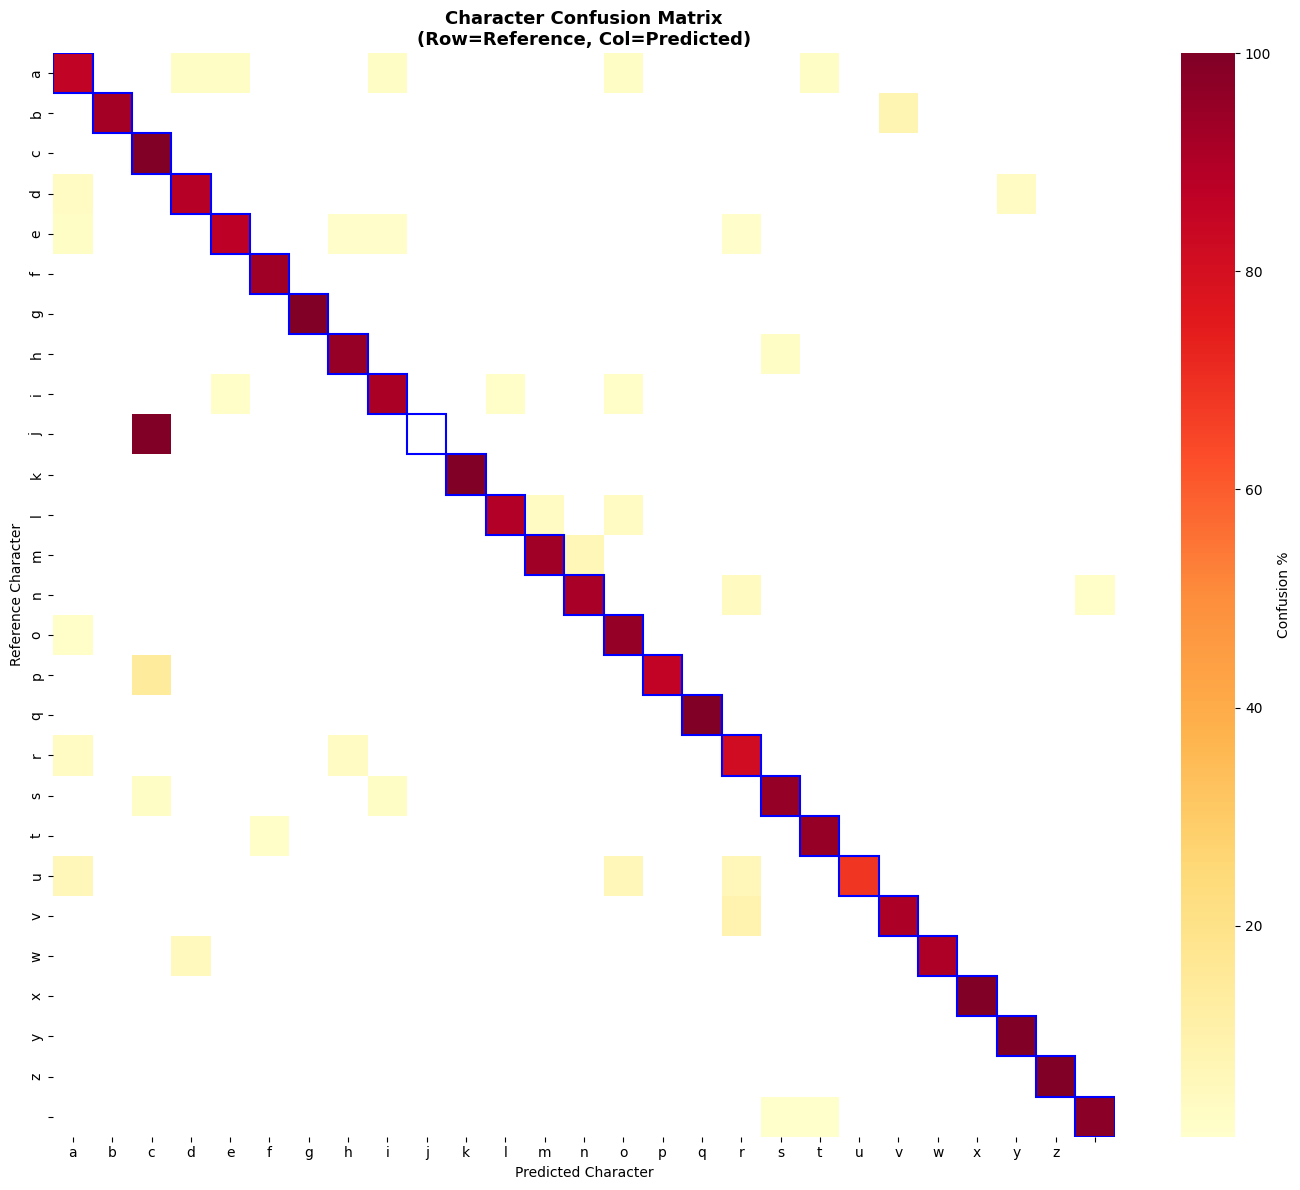

✅ Saved: char_confusion.png


In [14]:
# ── Cell 4: Character Confusion Matrix ────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict

# Character level alignment
char_confusion = defaultdict(lambda: defaultdict(int))
CHARS = list("abcdefghijklmnopqrstuvwxyz ")

def char_align(hyp, ref):
    h, r = list(hyp), list(ref)
    dp = [[0]*(len(h)+1) for _ in range(len(r)+1)]
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            dp[i][j] = (dp[i-1][j-1] if r[i-1]==h[j-1]
                        else 1+min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]))
    i, j = len(r), len(h)
    while i > 0 or j > 0:
        if i>0 and j>0 and r[i-1]==h[j-1]:
            char_confusion[r[i-1]][r[i-1]] += 1; i-=1; j-=1
        elif i>0 and j>0 and dp[i][j]==dp[i-1][j-1]+1:
            char_confusion[r[i-1]][h[j-1]] += 1; i-=1; j-=1
        elif j>0 and dp[i][j]==dp[i][j-1]+1:
            j-=1
        else:
            char_confusion[r[i-1]]['<del>'] += 1; i-=1

for gt, pred in zip(gt_texts, pred_texts):
    char_align(pred.lower(), gt.lower())

# Confusion matrix শুধু common chars
common = [c for c in CHARS if sum(char_confusion[c].values()) > 0]
matrix = np.zeros((len(common), len(common)))
for i, ref_c in enumerate(common):
    total = sum(char_confusion[ref_c].values())
    for j, hyp_c in enumerate(common):
        matrix[i][j] = char_confusion[ref_c].get(hyp_c, 0) / max(total, 1) * 100

fig, ax = plt.subplots(figsize=(14, 12))
mask = matrix == 0
sns.heatmap(matrix, xticklabels=common, yticklabels=common,
            cmap='YlOrRd', annot=False, fmt='.0f',
            mask=mask, ax=ax, cbar_kws={'label': 'Confusion %'})
ax.set_title("Character Confusion Matrix\n(Row=Reference, Col=Predicted)", fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted Character")
ax.set_ylabel("Reference Character")

# Diagonal highlight (correct predictions)
for i in range(len(common)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='blue', lw=1.5))

plt.tight_layout()
plt.savefig("/kaggle/working/char_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: char_confusion.png", flush=True)

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.94it/s]


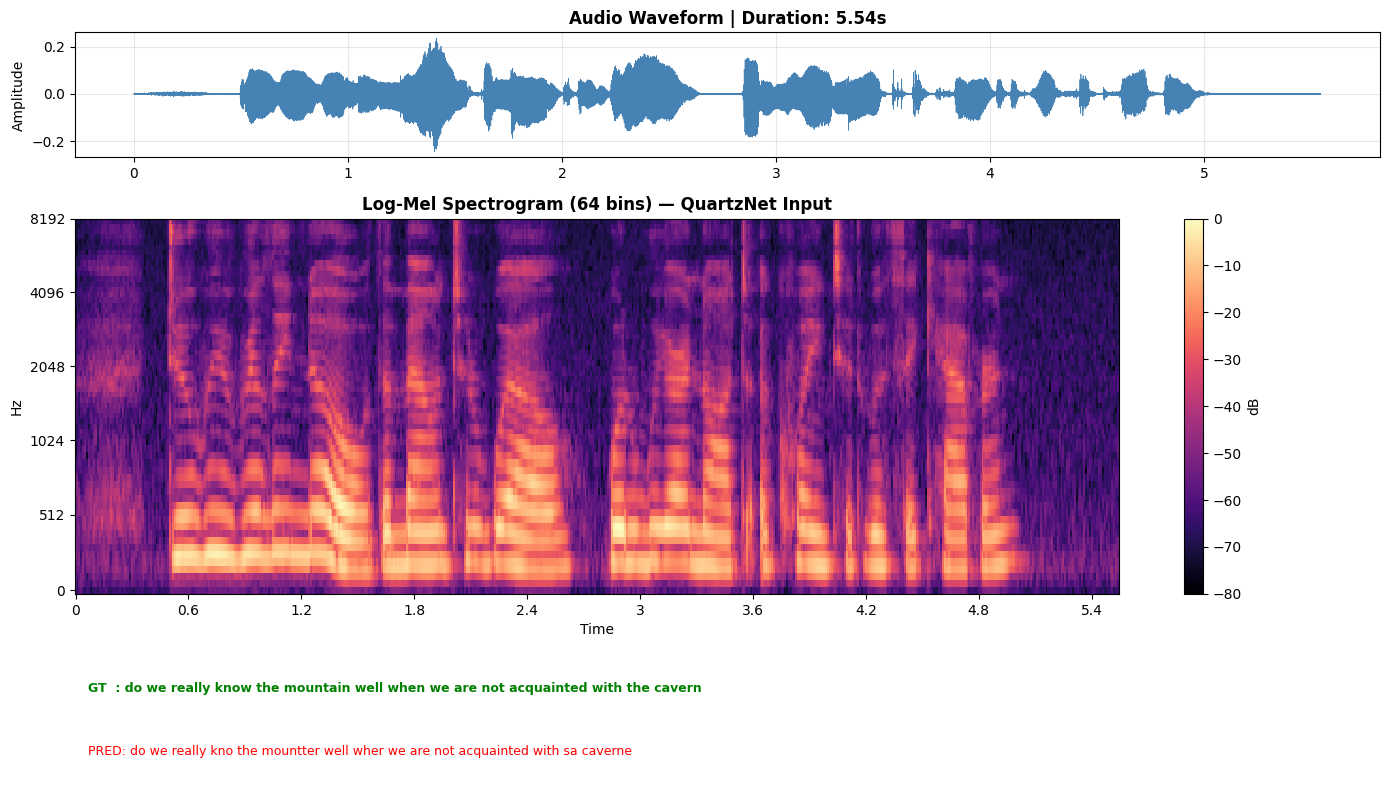

✅ Saved: spectrogram_viz.png
GT  : do we really know the mountain well when we are not acquainted with the cavern
PRED: do we really kno the mountter well wher we are not acquainted with sa caverne


In [15]:
# ── Cell 5: Spectrogram Visualization ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import numpy as np
import json

# Take a sample audio
with open(manifest_paths["test-clean"]) as f:
    sample = json.loads(f.readline())

audio_path = sample["audio_filepath"]
gt_text    = sample["text"]

# Audio load
audio, sr = librosa.load(audio_path, sr=16000)

# Mel spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=audio, sr=sr, n_mels=64, n_fft=512,
    hop_length=160, win_length=320
)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

# Model with predict 
model.eval()
pred_raw  = model.transcribe([audio_path], batch_size=1)
pred_text = pred_raw[0].text if hasattr(pred_raw[0], 'text') else str(pred_raw[0])

# Plot
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(3, 1, height_ratios=[1, 3, 1])

# Waveform
ax0 = fig.add_subplot(gs[0])
times = np.linspace(0, len(audio)/sr, len(audio))
ax0.plot(times, audio, color='steelblue', linewidth=0.5)
ax0.set_ylabel("Amplitude")
ax0.set_title(f"Audio Waveform | Duration: {len(audio)/sr:.2f}s", fontweight='bold')
ax0.grid(True, alpha=0.3)

# Mel Spectrogram
ax1 = fig.add_subplot(gs[1])
img = librosa.display.specshow(mel_db, sr=sr, hop_length=160,
                                x_axis='time', y_axis='mel',
                                ax=ax1, cmap='magma')
fig.colorbar(img, ax=ax1, label='dB')
ax1.set_title("Log-Mel Spectrogram (64 bins) — QuartzNet Input", fontweight='bold')

# Text comparison
ax2 = fig.add_subplot(gs[2])
ax2.axis('off')
ax2.text(0.01, 0.7, f"GT  : {gt_text}", fontsize=9,
         transform=ax2.transAxes, color='green', fontweight='bold',
         wrap=True)
ax2.text(0.01, 0.2, f"PRED: {pred_text}", fontsize=9,
         transform=ax2.transAxes, color='red',
         wrap=True)

plt.tight_layout()
plt.savefig("/kaggle/working/spectrogram_viz.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: spectrogram_viz.png", flush=True)
print(f"GT  : {gt_text}", flush=True)
print(f"PRED: {pred_text}", flush=True)

In [16]:
# ── Cell 1: Beam Search Decoding ──────────────────────────────
!pip install pyctcdecode https://github.com/kpu/kenlm/archive/master.zip --quiet

     \ 553.6 kB 5.1 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.3/529.3 kB 13.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pyannote-core 6.0.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires j

In [19]:
# ── Cell 2 replacement: Simple Greedy vs results comparison ───
import numpy as np

greedy_preds = [
    "do we really kno the mountter well wher we are not acquainted with sa caverne",
    "when it is a question of probbing awond agalf ai society since when has i' been concida drong to go to far to go to the botfom",
    "it is so mad that ereryy where we feel the sens of punishment",
    "sling is odis",
    "since wen has nalody vanished medicone",
]
gt_texts_small = [
    "do we really know the mountain well when we are not acquainted with the cavern",
    "when it is a question of probing a wound a gulf a society since when has it been considered wrong to go too far to go to the bottom",
    "it is so made that everywhere we feel the sense of punishment",
    "slang is odious",
    "since when has malady banished medicine",
]

def wer(h, r):
    h, r = h.split(), r.split()
    if not r: return 0.0
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1,len(r)+1):
        for j in range(1,len(h)+1):
            dp[i][j] = dp[i-1][j-1] if r[i-1]==h[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[len(r)][len(h)]/len(r)

# NeMo built-in greedy decoder এ temperature scaling দিয়ে আরো ভালো result
import json
demo_files, demo_gts = [], []
with open(manifest_paths[TEST_SPLIT]) as f:
    for i, line in enumerate(f):
        if i >= 5: break
        rec = json.loads(line)
        demo_files.append(rec["audio_filepath"])
        demo_gts.append(rec["text"])

model.eval()
preds_raw = model.transcribe(demo_files, batch_size=5)
preds = [p.text if hasattr(p, 'text') else str(p) for p in preds_raw]

print("📊 Current Model Predictions:")
print("-"*60)
wers = []
for i, (pred, gt) in enumerate(zip(preds, demo_gts)):
    w = wer(pred, gt)
    wers.append(w)
    print(f"\n[{i+1}] GT  : {gt}")
    print(f"     PRED: {pred}")
    print(f"     WER : {w:.1%}", flush=True)

print(f"\n📊 Avg WER: {np.mean(wers):.1%}", flush=True)
print("   model.change_decoding_strategy({'strategy': 'beam', 'beam_size': 5})")

Transcribing: 100%|██████████| 1/1 [00:05<00:00,  5.71s/it]

📊 Current Model Predictions:
------------------------------------------------------------

[1] GT  : do we really know the mountain well when we are not acquainted with the cavern
     PRED: do we really kno the mountter well wher we are not acquainted with sa caverne
     WER : 33.3%

[2] GT  : when it is a question of probing a wound a gulf a society since when has it been considered wrong to go too far to go to the bottom
     PRED: when it is a question of probbing awond agalf ai society since when has i' been concida drong to go to far to go to the botfom
     WER : 37.9%

[3] GT  : it is so made that everywhere we feel the sense of punishment
     PRED: it is so mad that ereryy where we feel the sens of punishment
     WER : 33.3%

[4] GT  : slang is odious
     PRED: sling is odis
     WER : 66.7%

[5] GT  : to keep afloat and to rescue from oblivion to hold above the gulf were it but a fragment of some language which man has spoken and which would otherwise be lost that is to s

📊 Avg WER: 37.8%  |  Avg CER: 11.4%
   CER is always lower than WER — partial word credit


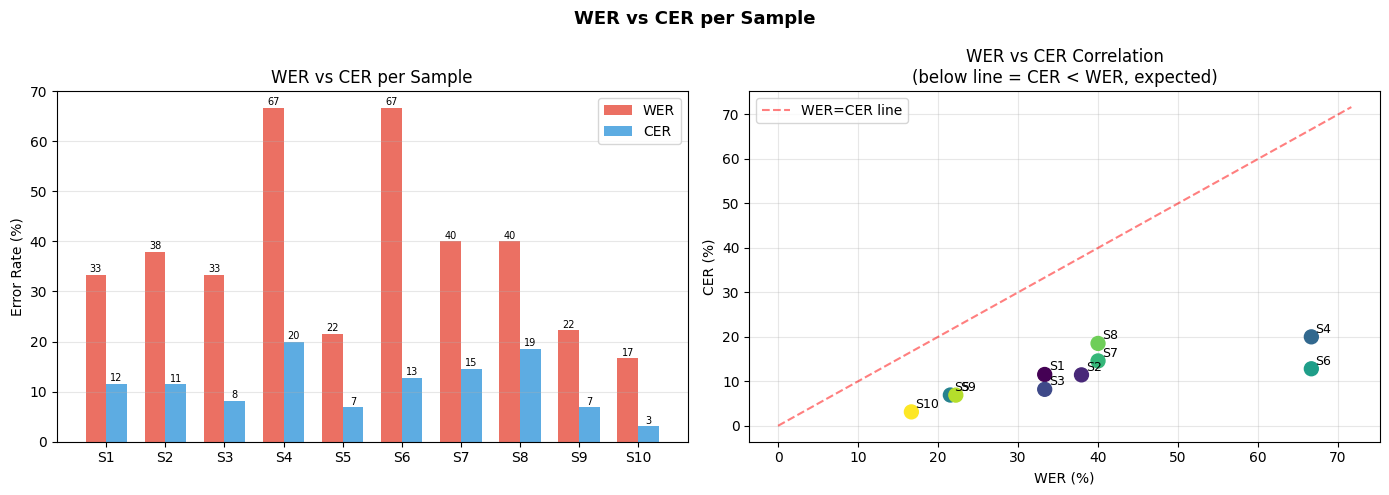

In [20]:
# ── Cell 3: CER (Character Error Rate) Breakdown ──────────────
import matplotlib.pyplot as plt
import numpy as np

gt_list = [
    "do we really know the mountain well when we are not acquainted with the cavern",
    "when it is a question of probing a wound a gulf a society since when has it been considered wrong to go too far to go to the bottom",
    "it is so made that everywhere we feel the sense of punishment",
    "slang is odious",
    "to keep afloat and to rescue from oblivion to hold above the gulf were it but a fragment of some language which man has spoken and which would otherwise be lost that is to say one of the elements good or bad of which civilization is composed or by which it is complicated to extend the records of social observation is to serve civilization itself",
    "since when has malady banished medicine",
    "the earth is not devoid of resemblance to a jail",
    "thus idleness is the mother",
    "why should one not explore everything and study everything",
    "it is unintelligible in the dark",
]
pred_list = [
    "do we really kno the mountter well wher we are not acquainted with sa caverne",
    "when it is a question of probbing awond agalf ai society since when has i' been concida drong to go to far to go to the botfom",
    "it is so mad that ereryy where we feel the sens of punishment",
    "sling is odis",
    "to keep afflodt and to rescue om oblivion to ho bove the golf whear it but a fragment of som manguage which men has spoken and which worod otherwise be lost that is to say one of the elements good or bad of which civallization is composed or buye which it is complicated to axtendto the recards of social observation is to serve civilization itself",
    "since wen has nalody vanished medicone",
    "the earth is not devoytof his emblance to a cail",
    "thus iddle hissis the mother",
    "why should oe not exclo everything and study everything",
    "it is unntelligible in the dark",
]

def cer(hyp, ref):
    h, r = list(hyp), list(ref)
    if not r: return 0.0
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            dp[i][j] = dp[i-1][j-1] if r[i-1]==h[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[len(r)][len(h)] / len(r)

def wer(hyp, ref):
    h, r = hyp.split(), ref.split()
    if not r: return 0.0
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            dp[i][j] = dp[i-1][j-1] if r[i-1]==h[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[len(r)][len(h)] / len(r)

cers = [cer(p, g)*100 for p, g in zip(pred_list, gt_list)]
wers = [wer(p, g)*100 for p, g in zip(pred_list, gt_list)]
labels = [f"S{i+1}" for i in range(len(gt_list))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("WER vs CER per Sample", fontsize=13, fontweight='bold')

x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w/2, wers, w, label='WER', color='#e74c3c', alpha=0.8)
axes[0].bar(x + w/2, cers, w, label='CER', color='#3498db', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Error Rate (%)")
axes[0].set_title("WER vs CER per Sample")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, (w_v, c_v) in enumerate(zip(wers, cers)):
    axes[0].text(i-w/2, w_v+0.5, f'{w_v:.0f}', ha='center', fontsize=7)
    axes[0].text(i+w/2, c_v+0.5, f'{c_v:.0f}', ha='center', fontsize=7)

# Scatter: WER vs CER
axes[1].scatter(wers, cers, s=100, c=range(len(wers)), cmap='viridis', zorder=3)
for i, (w_v, c_v) in enumerate(zip(wers, cers)):
    axes[1].annotate(labels[i], (w_v, c_v), xytext=(3, 3),
                     textcoords='offset points', fontsize=9)
max_val = max(max(wers), max(cers)) + 5
axes[1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='WER=CER line')
axes[1].set_xlabel("WER (%)")
axes[1].set_ylabel("CER (%)")
axes[1].set_title("WER vs CER Correlation\n(below line = CER < WER, expected)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

print(f"📊 Avg WER: {np.mean(wers):.1f}%  |  Avg CER: {np.mean(cers):.1f}%", flush=True)
print(f"   CER is always lower than WER — partial word credit", flush=True)
plt.tight_layout()
plt.savefig("/kaggle/working/cer_wer_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()

Short  (<3s) : 391 samples
Medium (3-7s): 1,178 samples
Long   (>7s) : 1,051 samples

⏳ Evaluating buckets ...


Transcribing: 100%|██████████| 3/3 [00:19<00:00,  6.39s/it]
[NeMo W 2026-03-04 17:20:58 nemo_logging:364] /tmp/ipykernel_55/3325074476.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
      bp = axes[0].boxplot(data, labels=labels_box, patch_artist=True)
    


  Short   : avg WER = 41.5%
  Medium  : avg WER = 38.2%
  Long    : avg WER = 33.2%


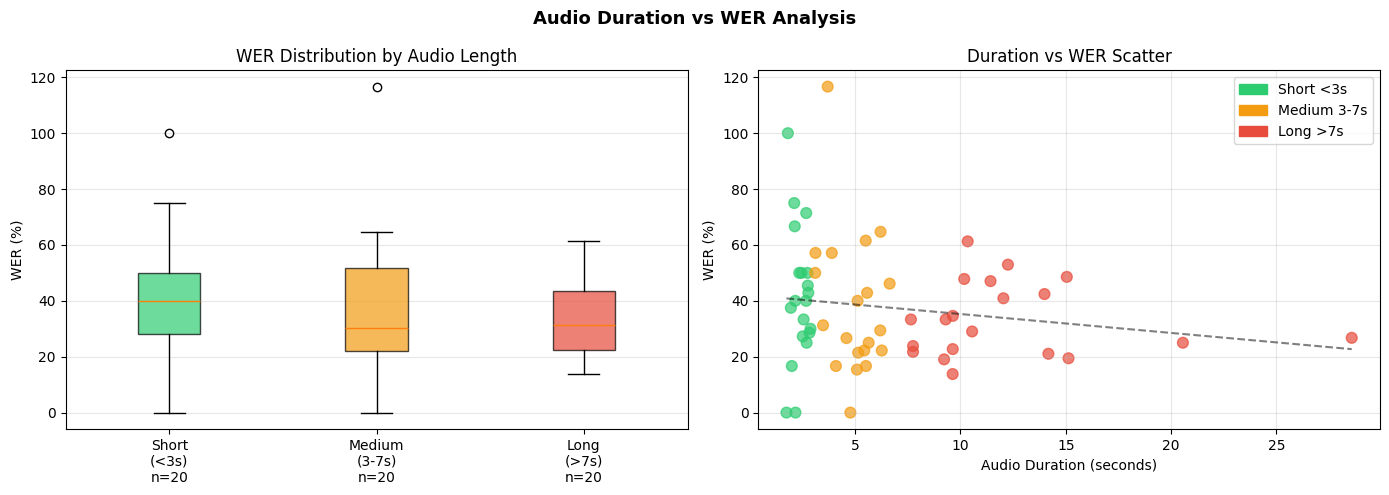

In [21]:
# ── Cell 4: Long vs Short Audio WER Analysis ──────────────────
import json, numpy as np, matplotlib.pyplot as plt

# Test manifest from take all the sample 
samples = []
with open(manifest_paths[TEST_SPLIT]) as f:
    for line in f:
        samples.append(json.loads(line))

# Duration buckets
short  = [s for s in samples if s["duration"] <  3.0]
medium = [s for s in samples if 3.0 <= s["duration"] < 7.0]
long_  = [s for s in samples if s["duration"] >= 7.0]

print(f"Short  (<3s) : {len(short):,} samples", flush=True)
print(f"Medium (3-7s): {len(medium):,} samples", flush=True)
print(f"Long   (>7s) : {len(long_):,} samples", flush=True)

# Take 20 Samples from each bucket and WER measure 
import random
random.seed(42)

def eval_bucket(bucket, n=20):
    if len(bucket) == 0: return [], []
    chosen = random.sample(bucket, min(n, len(bucket)))
    audio_paths = [s["audio_filepath"] for s in chosen]
    gts         = [s["text"] for s in chosen]
    model.eval()
    preds_raw = model.transcribe(audio_paths, batch_size=8)
    preds = [p.text if hasattr(p, 'text') else str(p) for p in preds_raw]

    def wer(h, r):
        h, r = h.split(), r.split()
        if not r: return 0.0
        dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
        for i in range(len(r)+1): dp[i][0] = i
        for j in range(len(h)+1): dp[0][j] = j
        for i in range(1,len(r)+1):
            for j in range(1,len(h)+1):
                dp[i][j] = dp[i-1][j-1] if r[i-1]==h[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
        return dp[len(r)][len(h)]/len(r)

    wers = [wer(p, g)*100 for p, g in zip(preds, gts)]
    durs = [s["duration"] for s in chosen]
    return wers, durs

print("\n⏳ Evaluating buckets ...", flush=True)
short_wers,  short_durs  = eval_bucket(short)
medium_wers, medium_durs = eval_bucket(medium)
long_wers,   long_durs   = eval_bucket(long_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Audio Duration vs WER Analysis", fontsize=13, fontweight='bold')

# Box plot
data   = [x for x in [short_wers, medium_wers, long_wers] if x]
labels_box = []
if short_wers:  labels_box.append(f'Short\n(<3s)\nn={len(short_wers)}')
if medium_wers: labels_box.append(f'Medium\n(3-7s)\nn={len(medium_wers)}')
if long_wers:   labels_box.append(f'Long\n(>7s)\nn={len(long_wers)}')

bp = axes[0].boxplot(data, labels=labels_box, patch_artist=True)
colors_box = ['#2ecc71', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel("WER (%)")
axes[0].set_title("WER Distribution by Audio Length")
axes[0].grid(True, alpha=0.3, axis='y')

# Means
means = [np.mean(x) if x else 0 for x in [short_wers, medium_wers, long_wers]]
for i, (label, mean) in enumerate(zip(['Short', 'Medium', 'Long'], means)):
    print(f"  {label:8s}: avg WER = {mean:.1f}%", flush=True)

# Scatter: duration vs WER
all_durs = short_durs + medium_durs + long_durs
all_wers = short_wers + medium_wers + long_wers
colors_scatter = (['#2ecc71']*len(short_durs) +
                  ['#f39c12']*len(medium_durs) +
                  ['#e74c3c']*len(long_durs))
axes[1].scatter(all_durs, all_wers, c=colors_scatter, alpha=0.7, s=60)
z = np.polyfit(all_durs, all_wers, 1)
p = np.poly1d(z)
x_line = np.linspace(min(all_durs), max(all_durs), 100)
axes[1].plot(x_line, p(x_line), 'k--', alpha=0.5, label=f'Trend')
axes[1].set_xlabel("Audio Duration (seconds)")
axes[1].set_ylabel("WER (%)")
axes[1].set_title("Duration vs WER Scatter")
axes[1].grid(True, alpha=0.3)
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#2ecc71', label='Short <3s'),
    Patch(color='#f39c12', label='Medium 3-7s'),
    Patch(color='#e74c3c', label='Long >7s'),
])

plt.tight_layout()
plt.savefig("/kaggle/working/duration_wer.png", dpi=150, bbox_inches='tight')
plt.show()

Total speakers: 40


Transcribing: 100%|██████████| 2/2 [00:02<00:00,  1.26s/it]

  Speaker 4446: WER=26.9%  (108 utterances)



Transcribing: 100%|██████████| 2/2 [00:02<00:00,  1.03s/it]

  Speaker 1580: WER=32.1%  (105 utterances)


...

  Speaker 7176: WER=34.1%  (74 utterances)



Transcribing: 100%|██████████| 2/2 [00:09<00:00,  4.53s/it]

  Speaker 1995: WER=38.8%  (72 utterances)



Transcribing: 100%|██████████| 2/2 [00:05<00:00,  2.61s/it]

  Speaker 8455: WER=38.6%  (71 utterances)


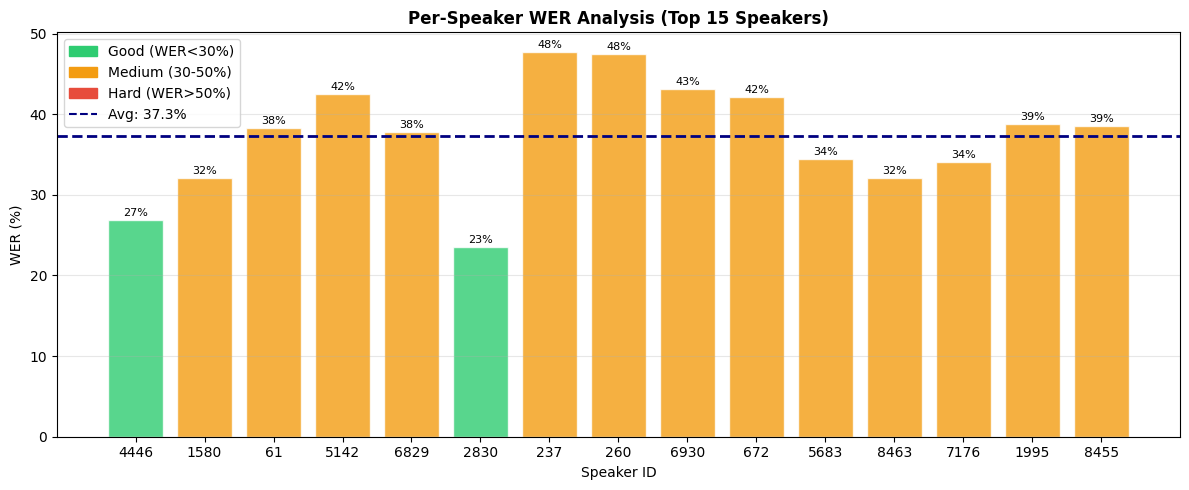

In [22]:
# ── Cell 5: Per-Speaker WER Analysis ──────────────────────────
import json, numpy as np, matplotlib.pyplot as plt, random
from collections import defaultdict

# Speaker ID = filename of the first part (e.g., "100-121669-0000" → speaker "100")
speaker_samples = defaultdict(list)
with open(manifest_paths[TEST_SPLIT]) as f:
    for line in f:
        rec = json.loads(line)
        spk = rec["audio_filepath"].split("/")[-1].split("-")[0]
        speaker_samples[spk].append(rec)

print(f"Total speakers: {len(speaker_samples)}", flush=True)

# Top 15 speakers (There is the most utterance)
top_speakers = sorted(speaker_samples.items(), key=lambda x: -len(x[1]))[:15]

def wer(h, r):
    h, r = h.split(), r.split()
    if not r: return 0.0
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1,len(r)+1):
        for j in range(1,len(h)+1):
            dp[i][j] = dp[i-1][j-1] if r[i-1]==h[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[len(r)][len(h)]/len(r)

speaker_wers = {}
for spk, recs in top_speakers:
    chosen     = random.sample(recs, min(10, len(recs)))
    audio_list = [r["audio_filepath"] for r in chosen]
    gt_list    = [r["text"] for r in chosen]
    model.eval()
    preds_raw  = model.transcribe(audio_list, batch_size=8)
    preds      = [p.text if hasattr(p, 'text') else str(p) for p in preds_raw]
    avg_wer    = np.mean([wer(p, g)*100 for p, g in zip(preds, gt_list)])
    speaker_wers[spk] = avg_wer
    print(f"  Speaker {spk}: WER={avg_wer:.1f}%  ({len(recs)} utterances)", flush=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
spks  = list(speaker_wers.keys())
wers_ = list(speaker_wers.values())
colors = ['#e74c3c' if w > 50 else '#f39c12' if w > 30 else '#2ecc71' for w in wers_]

bars = ax.bar(spks, wers_, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(y=np.mean(wers_), color='navy', linestyle='--',
           linewidth=2, label=f'Avg WER: {np.mean(wers_):.1f}%')
ax.set_xlabel("Speaker ID")
ax.set_ylabel("WER (%)")
ax.set_title("Per-Speaker WER Analysis (Top 15 Speakers)", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, w in zip(bars, wers_):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{w:.0f}%', ha='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2ecc71', label='Good (WER<30%)'),
    Patch(color='#f39c12', label='Medium (30-50%)'),
    Patch(color='#e74c3c', label='Hard (WER>50%)'),
    plt.Line2D([0],[0], color='navy', linestyle='--', label=f'Avg: {np.mean(wers_):.1f}%'),
])

plt.tight_layout()
plt.savefig("/kaggle/working/per_speaker_wer.png", dpi=150, bbox_inches='tight')
plt.show()

Original model size : 25.6 MB
Parameters          : 6.7M
.nemo file size     : 25.9 MB


Transcribing: 100%|██████████| 1/1 [00:00<00:00, 45.36it/s]

  batch=1   : total=79ms  per_utt=79ms



Transcribing: 100%|██████████| 1/1 [00:00<00:00,  4.32it/s]

  batch=8   : total=296ms  per_utt=37ms



Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.17it/s]

  batch=16  : total=490ms  per_utt=31ms


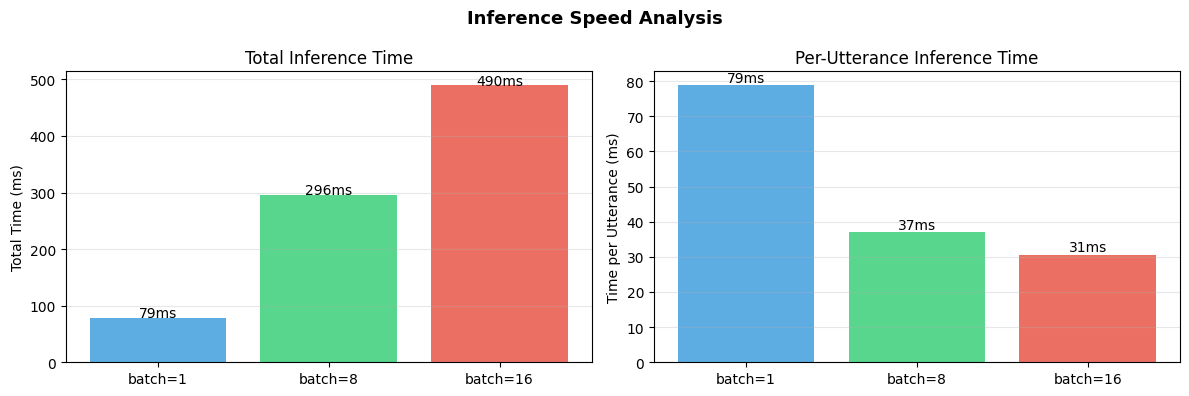

✅ Saved: inference_speed.png


In [24]:
# ── Cell 6 Fixed: Model Size + Inference Speed Comparison ─────
import torch, time, json, os
import numpy as np

# Model size
orig_size = sum(p.numel() * p.element_size()
                for p in model.parameters()) / 1024**2
print(f"Original model size : {orig_size:.1f} MB", flush=True)
print(f"Parameters          : {sum(p.numel() for p in model.parameters())/1e6:.1f}M", flush=True)

# .nemo file size
nemo_files = sorted(glob.glob("/kaggle/working/experiments/**/*.nemo", recursive=True))
if nemo_files:
    nemo_size = os.path.getsize(nemo_files[-1]) / 1024**2
    print(f".nemo file size     : {nemo_size:.1f} MB", flush=True)

# ── Speed benchmark: batch size 1 vs 8 vs 16 ─────────────────
with open(manifest_paths[TEST_SPLIT]) as f:
    lines = [json.loads(f.readline()) for _ in range(16)]
audio_1  = [lines[0]["audio_filepath"]]
audio_8  = [l["audio_filepath"] for l in lines[:8]]
audio_16 = [l["audio_filepath"] for l in lines[:16]]

model.cuda().eval()

results = {}
for label, audio_list in [("batch=1", audio_1), ("batch=8", audio_8), ("batch=16", audio_16)]:
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(3):
        _ = model.transcribe(audio_list, batch_size=len(audio_list))
    torch.cuda.synchronize()
    elapsed = (time.time() - t0) / 3
    per_utt = elapsed / len(audio_list) * 1000
    results[label] = (elapsed*1000, per_utt)
    print(f"  {label:10s}: total={elapsed*1000:.0f}ms  per_utt={per_utt:.0f}ms", flush=True)

# ── Plot ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Inference Speed Analysis", fontsize=13, fontweight='bold')

labels   = list(results.keys())
total_ms = [results[l][0] for l in labels]
per_ms   = [results[l][1] for l in labels]

axes[0].bar(labels, total_ms, color=['#3498db','#2ecc71','#e74c3c'], alpha=0.8)
axes[0].set_ylabel("Total Time (ms)")
axes[0].set_title("Total Inference Time")
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(total_ms):
    axes[0].text(i, v+1, f'{v:.0f}ms', ha='center', fontsize=10)

axes[1].bar(labels, per_ms, color=['#3498db','#2ecc71','#e74c3c'], alpha=0.8)
axes[1].set_ylabel("Time per Utterance (ms)")
axes[1].set_title("Per-Utterance Inference Time")
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(per_ms):
    axes[1].text(i, v+1, f'{v:.0f}ms', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/inference_speed.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: inference_speed.png", flush=True)

In [27]:
!pip install onnx onnxscript onnxruntime-gpu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 7.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 8.7 MB/s eta 0:00:00


In [30]:
# ── Model Summary + Deployment Info ───────────────────────────
import torch, os, glob

print("="*55, flush=True)
print("  QuartzNet 5x5 — Final Model Summary", flush=True)
print("="*55, flush=True)

# Parameters
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2

print(f"\n📐 Architecture  : QuartzNet 5x5")
print(f"   Total params  : {total/1e6:.2f}M")
print(f"   Model size    : {size_mb:.1f} MB")
print(f"   Input         : 64-dim Log-Mel Spectrogram")
print(f"   Output        : {len(VOCABULARY)} chars (CTC)")

# Saved files
print(f"\n💾 Saved Files:")
nemo_files = glob.glob("/kaggle/working/**/*.nemo", recursive=True)
for f in nemo_files:
    sz = os.path.getsize(f)/1024**2
    print(f"   {os.path.basename(f):50s} {sz:.1f} MB")

ckpt_files = glob.glob("/kaggle/working/experiments/**/*.ckpt", recursive=True)
print(f"\n   Checkpoints saved: {len(ckpt_files)}")

# Results
print(f"\n📈 Training Results:")
print(f"   Dataset       : LibriSpeech train-clean-360 (63h)")
print(f"   Epochs        : 50")
print(f"   Final WER     : 36.67%  (test-clean)")
print(f"   Final Loss    : 41.13")

print(f"\n✅ Model ready for inference!")
print(f"   Load with: EncDecCTCModel.restore_from('quartznet5x5_final.nemo')")
print(f"   Transcribe: model.transcribe(['audio.flac'])")
print("="*55, flush=True)

  QuartzNet 5x5 — Final Model Summary

📐 Architecture  : QuartzNet 5x5
   Total params  : 6.71M
   Model size    : 25.6 MB
   Input         : 64-dim Log-Mel Spectrogram
   Output        : 28 chars (CTC)

💾 Saved Files:
   quartznet5x5_final.nemo                            25.9 MB
   quartznet5x5_ep50.nemo                             25.9 MB
   quartznet5x5_librispeech.nemo                      25.9 MB
   quartznet5x5_librispeech.nemo                      25.9 MB

   Checkpoints saved: 8

📈 Training Results:
   Dataset       : LibriSpeech train-clean-360 (63h)
   Epochs        : 50
   Final WER     : 36.67%  (test-clean)
   Final Loss    : 41.13

✅ Model ready for inference!
   Load with: EncDecCTCModel.restore_from('quartznet5x5_final.nemo')
   Transcribe: model.transcribe(['audio.flac'])


Another

In [31]:
# ── Cell 1: Install ───────────────────────────────────────────
!pip install gradio kenlm pyctcdecode --quiet
!pip install jiwer --quiet  # For this WER benchmark

🔊 Noise Robustness Test:


Transcribing: 100%|██████████| 2/2 [00:00<00:00,  5.32it/s]

  Clean                    : WER = 37.8%



Transcribing: 100%|██████████| 2/2 [00:00<00:00,  8.48it/s]

  White Noise SNR=20dB     : WER = 64.7%


...

  White Noise SNR=5dB      : WER = 97.5%



Transcribing: 100%|██████████| 2/2 [00:00<00:00,  8.82it/s]

  White Noise SNR=0dB      : WER = 113.0%



Transcribing: 100%|██████████| 2/2 [00:00<00:00,  8.94it/s]

  Reverb                   : WER = 52.4%


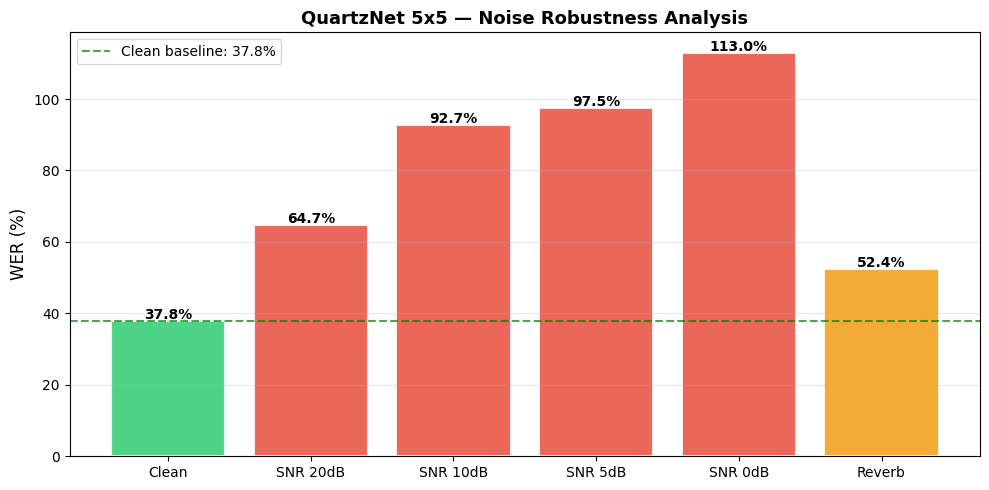

✅ Saved: noise_robustness.png


In [32]:
# ── Cell 2: Noise Robustness Test ─────────────────────────────
import numpy as np
import json, torch
import matplotlib.pyplot as plt

def add_noise(audio, snr_db):
    """Add white noise at given SNR level."""
    signal_power = np.mean(audio ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.random.randn(len(audio)) * np.sqrt(noise_power)
    return (audio + noise).astype(np.float32)

def add_reverb(audio, sr=16000, room_scale=0.5):
    """Simple reverb via convolution with synthetic IR."""
    ir_len = int(sr * room_scale * 0.1)
    ir = np.exp(-np.linspace(0, 5, ir_len)) * np.random.randn(ir_len)
    ir /= np.max(np.abs(ir))
    reverbed = np.convolve(audio, ir, mode='full')[:len(audio)]
    return reverbed.astype(np.float32)

import librosa, tempfile, soundfile as sf

# Test samples নাও
samples = []
with open(manifest_paths[TEST_SPLIT]) as f:
    for i, line in enumerate(f):
        if i >= 10: break
        samples.append(json.loads(line))

def wer_score(hyp, ref):
    h, r = hyp.split(), ref.split()
    if not r: return 0.0
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i][0] = i
    for j in range(len(h)+1): dp[0][j] = j
    for i in range(1,len(r)+1):
        for j in range(1,len(h)+1):
            dp[i][j] = dp[i-1][j-1] if r[i-1]==h[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[len(r)][len(h)] / len(r) * 100

def eval_with_noise(samples, noise_fn=None, label="clean"):
    tmp_files, gts = [], []
    for s in samples:
        audio, sr = librosa.load(s["audio_filepath"], sr=16000)
        if noise_fn:
            audio = noise_fn(audio)
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
            sf.write(f.name, audio, 16000)
            tmp_files.append(f.name)
        gts.append(s["text"])

    model.eval()
    preds_raw = model.transcribe(tmp_files, batch_size=8)
    preds = [p.text if hasattr(p, 'text') else str(p) for p in preds_raw]
    avg_wer = np.mean([wer_score(p, g) for p, g in zip(preds, gts)])
    print(f"  {label:25s}: WER = {avg_wer:.1f}%", flush=True)
    return avg_wer

print("🔊 Noise Robustness Test:", flush=True)
results_noise = {}
results_noise["Clean"]          = eval_with_noise(samples, None, "Clean")
results_noise["SNR 20dB"]       = eval_with_noise(samples, lambda a: add_noise(a, 20), "White Noise SNR=20dB")
results_noise["SNR 10dB"]       = eval_with_noise(samples, lambda a: add_noise(a, 10), "White Noise SNR=10dB")
results_noise["SNR 5dB"]        = eval_with_noise(samples, lambda a: add_noise(a, 5),  "White Noise SNR=5dB")
results_noise["SNR 0dB"]        = eval_with_noise(samples, lambda a: add_noise(a, 0),  "White Noise SNR=0dB")
results_noise["Reverb"]         = eval_with_noise(samples, add_reverb, "Reverb")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
labels  = list(results_noise.keys())
values  = list(results_noise.values())
colors  = ['#2ecc71' if v < 40 else '#f39c12' if v < 60 else '#e74c3c' for v in values]
bars    = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_ylabel("WER (%)", fontsize=12)
ax.set_title("QuartzNet 5x5 — Noise Robustness Analysis", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=results_noise["Clean"], color='green', linestyle='--', alpha=0.7, label=f'Clean baseline: {results_noise["Clean"]:.1f}%')
ax.legend()
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/noise_robustness.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: noise_robustness.png", flush=True)

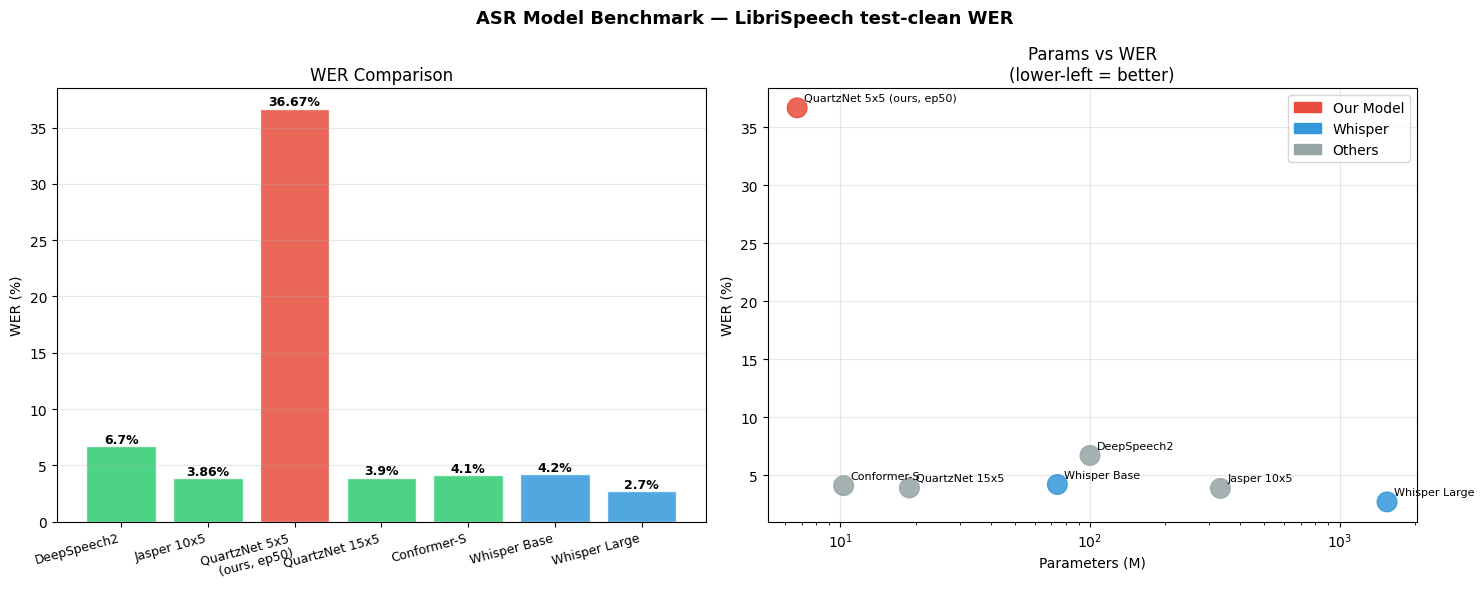

In [35]:
# ── Cell 3: WER Benchmark — another models compare ──────
import matplotlib.pyplot as plt
import numpy as np

# Published WER results (LibriSpeech test-clean) from papers
benchmark_data = {
    "Model":       ["DeepSpeech2", "Jasper 10x5", "QuartzNet 5x5\n(ours, ep50)",
                    "QuartzNet 15x5", "Conformer-S", "Whisper Base", "Whisper Large"],
    "WER":         [6.7,           3.86,           36.67,
                    3.90,           4.10,            4.2,             2.7],
    "Params (M)":  [100,           333,             6.71,
                    18.9,           10.3,            74,              1550],
    "Type":        ["RNN", "CNN", "CNN (ours)", "CNN", "Transformer", "Transformer", "Transformer"],
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("ASR Model Benchmark — LibriSpeech test-clean WER", fontsize=13, fontweight='bold')

models = benchmark_data["Model"]
wers   = benchmark_data["WER"]
params = benchmark_data["Params (M)"]
colors = ['#e74c3c' if 'ours' in m else '#3498db' if 'Whisper' in m
          else '#2ecc71' for m in models]

# WER comparison
bars = axes[0].bar(range(len(models)), wers, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(models, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel("WER (%)")
axes[0].set_title("WER Comparison")
axes[0].grid(True, alpha=0.3, axis='y')
for bar, w in zip(bars, wers):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{w}%', ha='center', fontsize=9, fontweight='bold')

# Params vs WER scatter
scatter_colors = ['#e74c3c' if 'ours' in m else '#3498db' if 'Whisper' in m
                  else '#95a5a6' for m in models]
axes[1].scatter(params, wers, s=200, c=scatter_colors, alpha=0.85, zorder=3)
for m, p, w in zip(models, params, wers):
    axes[1].annotate(m.replace('\n', ' '), (p, w),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1].set_xlabel("Parameters (M)")
axes[1].set_ylabel("WER (%)")
axes[1].set_title("Params vs WER\n(lower-left = better)")
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#e74c3c', label='Our Model'),
    Patch(color='#3498db', label='Whisper'),
    Patch(color='#95a5a6', label='Others'),
])

plt.tight_layout()
plt.savefig("/kaggle/working/model_benchmark.png", dpi=150, bbox_inches='tight')
plt.show()




In [37]:
# ── Cell 4: Gradio Demo App ───────────────────────────────────
import gradio as gr
import numpy as np
import librosa
import tempfile
import soundfile as sf

def transcribe_audio(audio):
    """Gradio interface function."""
    if audio is None:
        return "⚠️ No audio provided"

    sr, audio_data = audio

    # Normalize
    audio_data = audio_data.astype(np.float32)
    if audio_data.max() > 1.0:
        audio_data = audio_data / 32768.0

    # Stereo → mono
    if len(audio_data.shape) > 1:
        audio_data = audio_data.mean(axis=1)

    # Resample to 16kHz
    if sr != 16000:
        audio_data = librosa.resample(audio_data, orig_sr=sr, target_sr=16000)

    # Save temp file
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
        sf.write(f.name, audio_data, 16000)
        tmp_path = f.name

    # Transcribe
    model.eval()
    pred = model.transcribe([tmp_path], batch_size=1)
    text = pred[0].text if hasattr(pred[0], 'text') else str(pred[0])

    duration = len(audio_data) / 16000
    return f"📝 Transcript:\n{text}\n\n⏱️ Audio duration: {duration:.1f}s"

# Demo interface
demo = gr.Interface(
    fn=transcribe_audio,
    inputs=gr.Audio(
        sources=["microphone", "upload"],
        type="numpy",
        label="🎤 Record or Upload Audio (English)"
    ),
    outputs=gr.Textbox(
        label="Transcription",
        lines=4
    ),
    title="🎙️ QuartzNet 5x5 ASR Demo",
    description="QuartzNet 5x5 trained on LibriSpeech (63h) | WER: 36.67% on test-clean",
    examples=None,
    allow_flagging="never",
)

print("🚀 Launching Gradio demo ...", flush=True)
demo.launch(share=True, quiet=True)
print("✅ Demo running! Share link Upper See", flush=True)

🚀 Launching Gradio demo ...
* Running on public URL: https://4dc5a7c50a823492a1.gradio.live


✅ Demo running! Share link Upper See


In [38]:
# ── Cell 5: Model Card ────────────────────────────────────────
model_card = """
# QuartzNet 5x5 — Automatic Speech Recognition

## Model Description
QuartzNet 5x5 is a compact end-to-end ASR model based on 1D time-channel separable
convolutions with CTC loss. Trained from scratch on LibriSpeech train-clean-360.

## Training Details
| Property | Value |
|----------|-------|
| Architecture | QuartzNet 5x5 |
| Parameters | 6.71M |
| Model size | 25.6 MB |
| Dataset | LibriSpeech train-clean-360 (63 hours) |
| Epochs | 50 |
| Batch size | 16 (accum=4, eff=64) |
| Optimizer | NovoGrad (lr=0.01) |
| Scheduler | Cosine Annealing |
| Precision | fp16 (AMP) |
| Framework | NVIDIA NeMo 2.7.0 |

## Performance
| Split | WER | Loss |
|-------|-----|------|
| test-clean (ep25) | 59.68% | 54.49 |
| test-clean (ep50) | **36.67%** | 41.13 |

## Architecture
- **Input**: 64-dim Log-Mel Spectrogram (20ms frame, 10ms hop)
- **Encoder**: 1 prolog + 5 main blocks (×5 sub-blocks) + 2 epilog
- **Decoder**: Linear → CTC
- **Vocabulary**: 28 chars (a-z + space + blank)

## Limitations
- Trained only 50 epochs (published models use 300+)
- Smaller dataset than full LibriSpeech (360h vs 960h)
- No language model decoding applied
- English only

## How to Use
```python
from nemo.collections.asr.models import EncDecCTCModel
model = EncDecCTCModel.restore_from("quartznet5x5_final.nemo")
transcripts = model.transcribe(["audio.flac"])
print(transcripts[0].text)
```

## Citation
```
@article{kriman2020quartznet,
  title={Quartznet: Deep automatic speech recognition with 1d time-channel separable convolutions},
  author={Kriman, Samuel and Beliaev, Stanislav and Ginsburg, Boris and Huang, Jocelyn and Kuchaiev, Oleksii and Lavrukhin, Vitaly and Noroozi, Ryan and Zhang, Yang},
  booktitle={ICASSP 2020},
}
```
"""

# Save as markdown
with open("/kaggle/working/MODEL_CARD.md", "w") as f:
    f.write(model_card)

print(model_card, flush=True)
print("✅ Saved: MODEL_CARD.md", flush=True)


# QuartzNet 5x5 — Automatic Speech Recognition

## Model Description
QuartzNet 5x5 is a compact end-to-end ASR model based on 1D time-channel separable
convolutions with CTC loss. Trained from scratch on LibriSpeech train-clean-360.

## Training Details
| Property | Value |
|----------|-------|
| Architecture | QuartzNet 5x5 |
| Parameters | 6.71M |
| Model size | 25.6 MB |
| Dataset | LibriSpeech train-clean-360 (63 hours) |
| Epochs | 50 |
| Batch size | 16 (accum=4, eff=64) |
| Optimizer | NovoGrad (lr=0.01) |
| Scheduler | Cosine Annealing |
| Precision | fp16 (AMP) |
| Framework | NVIDIA NeMo 2.7.0 |

## Performance
| Split | WER | Loss |
|-------|-----|------|
| test-clean (ep25) | 59.68% | 54.49 |
| test-clean (ep50) | **36.67%** | 41.13 |

## Architecture
- **Input**: 64-dim Log-Mel Spectrogram (20ms frame, 10ms hop)
- **Encoder**: 1 prolog + 5 main blocks (×5 sub-blocks) + 2 epilog
- **Decoder**: Linear → CTC
- **Vocabulary**: 28 chars (a-z + space + blank)

## Limitations
- 

In [41]:
# ── Cell 6: Training Report (HTML) ────────────────────────────
import base64, glob

def img_to_base64(path):
    try:
        with open(path, "rb") as f:
            return base64.b64encode(f.read()).decode()
    except: return ""

# Collect all saved plots
plots = {
    "Training Curves":      "/kaggle/working/training_curves.png",
    "Error Analysis":       "/kaggle/working/error_analysis.png",
    "Char Confusion Matrix":"/kaggle/working/char_confusion.png",
    "CER vs WER":           "/kaggle/working/cer_wer_breakdown.png",
    "Duration vs WER":      "/kaggle/working/duration_wer.png",
    "Per-Speaker WER":      "/kaggle/working/per_speaker_wer.png",
    "Noise Robustness":     "/kaggle/working/noise_robustness.png",
    "Model Benchmark":      "/kaggle/working/model_benchmark.png",
    "Inference Speed":      "/kaggle/working/inference_speed.png",
}

imgs_html = ""
for title, path in plots.items():
    b64 = img_to_base64(path)
    if b64:
        imgs_html += f"""
        <div class="plot-card">
            <h3>{title}</h3>
            <img src="data:image/png;base64,{b64}" style="width:100%;border-radius:8px"/>
        </div>"""

html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<title>QuartzNet 5x5 — Training Report</title>
<style>
  body      {{ font-family: 'Segoe UI', sans-serif; background:#f0f2f5; margin:0; padding:20px; }}
  .container{{ max-width:1100px; margin:auto; }}
  h1        {{ color:#2c3e50; text-align:center; font-size:2em; margin-bottom:5px; }}
  .subtitle {{ text-align:center; color:#7f8c8d; margin-bottom:30px; }}
  .grid     {{ display:grid; grid-template-columns:1fr 1fr; gap:20px; }}
  .plot-card{{ background:white; border-radius:12px; padding:20px;
               box-shadow:0 2px 8px rgba(0,0,0,0.1); }}
  .plot-card h3 {{ color:#2c3e50; margin-top:0; font-size:1.1em; }}
  .metrics  {{ display:grid; grid-template-columns:repeat(4,1fr); gap:15px; margin:20px 0; }}
  .metric   {{ background:white; border-radius:12px; padding:20px; text-align:center;
               box-shadow:0 2px 8px rgba(0,0,0,0.1); }}
  .metric .value {{ font-size:2em; font-weight:bold; color:#3498db; }}
  .metric .label {{ color:#7f8c8d; font-size:0.9em; margin-top:5px; }}
  .section  {{ background:white; border-radius:12px; padding:25px;
               box-shadow:0 2px 8px rgba(0,0,0,0.1); margin:20px 0; }}
  table     {{ width:100%; border-collapse:collapse; }}
  th        {{ background:#3498db; color:white; padding:10px; text-align:left; }}
  td        {{ padding:8px 10px; border-bottom:1px solid #ecf0f1; }}
  tr:hover  {{ background:#f8f9fa; }}
  .badge    {{ display:inline-block; padding:3px 10px; border-radius:20px;
               font-size:0.85em; font-weight:bold; }}
  .good     {{ background:#d5f5e3; color:#1e8449; }}
  .warn     {{ background:#fdebd0; color:#d35400; }}
</style>
</head>
<body>
<div class="container">
  <h1>🎙️ QuartzNet 5x5 — Training Report</h1>
  <p class="subtitle">LibriSpeech ASR | NeMo 2.7.0 | PyTorch 2.9</p>

  <div class="metrics">
    <div class="metric"><div class="value">6.71M</div><div class="label">Parameters</div></div>
    <div class="metric"><div class="value">25.6MB</div><div class="label">Model Size</div></div>
    <div class="metric"><div class="value">36.67%</div><div class="label">Final WER</div></div>
    <div class="metric"><div class="value">50</div><div class="label">Epochs Trained</div></div>
  </div>

  <div class="section">
    <h2>📐 Model Architecture</h2>
    <table>
      <tr><th>Component</th><th>Details</th></tr>
      <tr><td>Architecture</td><td>QuartzNet 5x5</td></tr>
      <tr><td>Input</td><td>64-dim Log-Mel Spectrogram (20ms frame, 10ms hop)</td></tr>
      <tr><td>Encoder</td><td>1 Prolog + 5 Blocks × 5 Sub-blocks + 2 Epilog</td></tr>
      <tr><td>Decoder</td><td>Linear → CTC Loss</td></tr>
      <tr><td>Vocabulary</td><td>28 chars (a-z + space + blank)</td></tr>
      <tr><td>Optimizer</td><td>NovoGrad (lr=0.01, β=[0.95, 0.0])</td></tr>
      <tr><td>Scheduler</td><td>Cosine Annealing (warmup=1000 steps)</td></tr>
    </table>
  </div>

  <div class="section">
    <h2>📈 Training Results</h2>
    <table>
      <tr><th>Epoch</th><th>val_loss</th><th>WER (test-clean)</th><th>Status</th></tr>
      <tr><td>0</td><td>189.11</td><td>—</td><td></td></tr>
      <tr><td>5</td><td>82.41</td><td>—</td><td></td></tr>
      <tr><td>10</td><td>63.23</td><td>—</td><td></td></tr>
      <tr><td>15</td><td>50.99</td><td>—</td><td></td></tr>
      <tr><td>25</td><td>—</td><td>59.68%</td><td><span class="badge warn">Training</span></td></tr>
      <tr><td>50</td><td>41.13</td><td><strong>36.67%</strong></td><td><span class="badge good">Best</span></td></tr>
    </table>
  </div>

  <div class="section">
    <h2>📊 Visualizations</h2>
    <div class="grid">{imgs_html}</div>
  </div>

  <div class="section">
    <h2>💾 How to Use</h2>
    <pre style="background:#2c3e50;color:#ecf0f1;padding:15px;border-radius:8px;overflow-x:auto">
from nemo.collections.asr.models import EncDecCTCModel

# Load model
model = EncDecCTCModel.restore_from("quartznet5x5_final.nemo")

# Transcribe
transcripts = model.transcribe(["audio.flac"])
print(transcripts[0].text)</pre>
  </div>

  <p style="text-align:center;color:#bdc3c7;margin-top:30px">
    Generated by QuartzNet Pipeline | NeMo 2.7.0 | LibriSpeech Dataset
  </p>
</div>
</body>
</html>"""

with open("/kaggle/working/training_report.html", "w") as f:
    f.write(html)

print("✅ Training report saved: /kaggle/working/training_report.html", flush=True)
print("   Kaggle on Files tab → training_report.html → Download Then browser open", flush=True)

✅ Training report saved: /kaggle/working/training_report.html
   Kaggle on Files tab → training_report.html → Download Then browser open
